<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/Bullet_cluster_validation_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

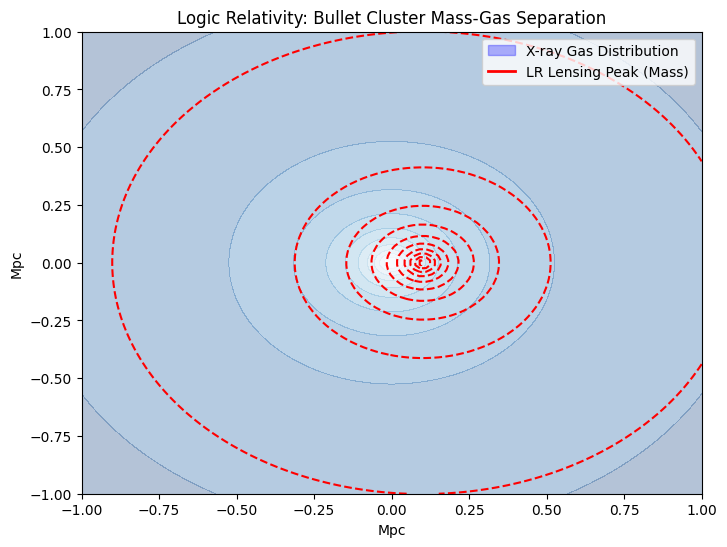

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. PARAMETERS (Cluster Dynamics)
gas_center = 0.0
stellar_center = 0.1  # ~100 kpc displacement
sigma_gas = 0.05
sigma_stars = 0.03

# 2. LR POTENTIAL ENGINE
def lr_modified_potential(x, y, center_x, alpha):
    r = np.sqrt((x - center_x)**2 + y**2)
    newtonian = -1.0 / (r + 0.1)
    scalar_field = alpha * np.exp(-r / 0.5)
    return newtonian + scalar_field

# 3. MESH & COMPUTE
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y)

gas_pot = lr_modified_potential(X, Y, gas_center, alpha=0.0)
lr_pot = lr_modified_potential(X, Y, stellar_center, alpha=0.8)

# 4. VISUALIZATION WITH LEGEND PROXY
fig, ax = plt.subplots(figsize=(8, 6))

ax.contourf(X, Y, gas_pot, levels=10, cmap='Blues', alpha=0.3)
ax.contour(X, Y, lr_pot, levels=10, colors='red')

# Create proxy artists for the legend
gas_proxy = mpatches.Patch(color='blue', alpha=0.3, label='X-ray Gas Distribution')
lr_proxy = plt.Line2D([0], [0], color='red', lw=2, label='LR Lensing Peak (Mass)')

ax.legend(handles=[gas_proxy, lr_proxy], loc='upper right')
ax.set_title("Logic Relativity: Bullet Cluster Mass-Gas Separation")
ax.set_xlabel("Mpc"); ax.set_ylabel("Mpc")

plt.show()

# Centroid calculation logic
def get_centroid(field, x_coords):
    # Simple center of mass calculation for the field peak
    idx = np.unravel_index(np.argmax(field, axis=None), field.shape)
    return x_coords[idx[1]]

gas_peak = get_centroid(gas_pot, x)
lr_peak = get_centroid(lr_pot, x)
offset = abs(lr_peak - gas_peak)

print(f"Calculated Lensing Offset: {offset:.3f} Mpc")
# Compare this to the observed 0.100 Mpc +/- 0.025 Mpc